ASSIGNMENT 6

    Date: April 21, 2026
    Course: CSCI E222 Foundations of Large Language Models

## Problem 1 Full Fine-Tuning vs LoRA PEFT

In [2]:
# ============================================================
## Full Fine-Tuning Model
# ============================================================
!pip install transformers datasets evaluate scikit-learn matplotlib -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# 1. Load Dataset
imdb = load_dataset("imdb")

# subsample training set
train_sample = imdb["train"].shuffle(seed=42).select(range(5000))
train_valid = train_sample.train_test_split(test_size=0.2, seed=42)
train_data = train_valid["train"]
val_data = train_valid["test"]
test_data = imdb["test"]


# 2. Tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True,
                     padding="max_length", max_length=128)

train_data = train_data.map(tokenize, batched=True)
val_data   = val_data.map(tokenize, batched=True)
test_data  = test_data.map(tokenize, batched=True)

train_data.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format("torch", columns=["input_ids", "attention_mask", "label"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Helper for calculating metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
        }

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.488585,0.341674,0.848000,0.817844,0.890688,0.852713
2,0.272216,0.361769,0.845000,0.838323,0.850202,0.844221
3,0.135933,0.478180,0.856000,0.837838,0.878543,0.857708
4,0.051270,0.661038,0.846000,0.861702,0.819838,0.840249
5,0.032563,0.833920,0.835000,0.840580,0.821862,0.831116
6,0.024612,0.891932,0.850000,0.846774,0.850202,0.848485
7,0.015106,0.929916,0.840000,0.823643,0.860324,0.841584
8,0.004638,1.036135,0.838000,0.802920,0.890688,0.844530
9,0.006163,1.025851,0.845000,0.815642,0.886640,0.849661
10,0.001703,1.079289,0.845000,0.839679,0.848178,0.843907


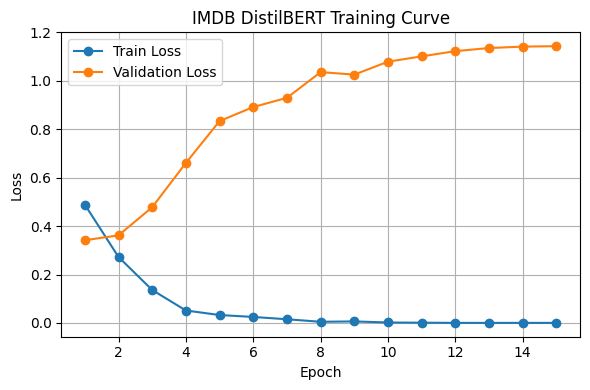


Test Results:
eval_loss: 1.1324
eval_accuracy: 0.8489
eval_precision: 0.8330
eval_recall: 0.8728
eval_f1: 0.8524
eval_runtime: 25.7716
eval_samples_per_second: 970.0600
eval_steps_per_second: 30.3430
epoch: 15.0000


In [3]:
# 3. Model (FULL fine-tune)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print("Model loaded...")

# 4. Training Arguments
training_args = TrainingArguments(
    output_dir="./imdb_model",

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=15,

    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    fp16=True,  # for GPU

    dataloader_num_workers=0,
    gradient_accumulation_steps=1
)


# 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()


# 6. LOSS PLOTTING
def plot_losses(log_history):
    train_loss = []
    eval_loss = []
    epochs_train = []
    epochs_eval = []

    for log in log_history:
        if "loss" in log:
            train_loss.append(log["loss"])
            epochs_train.append(log["epoch"])
        if "eval_loss" in log:
            eval_loss.append(log["eval_loss"])
            epochs_eval.append(log["epoch"])

    plt.figure(figsize=(6,4))

    if train_loss:
        plt.plot(epochs_train, train_loss, label="Train Loss", marker="o")

    if eval_loss:
        plt.plot(epochs_eval, eval_loss, label="Validation Loss", marker="o")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("IMDB DistilBERT Training Curve")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

plot_losses(trainer.state.log_history)


# 7. Final Evaluation
results = trainer.evaluate(test_data)

print("\nTest Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.634933,0.517830,0.811000,0.793834,0.834008,0.813425
2,0.470141,0.416296,0.821000,0.830189,0.801619,0.815654


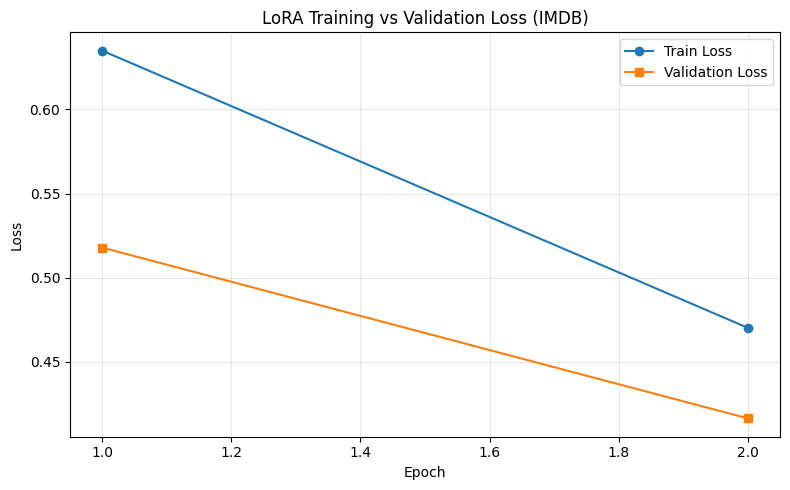


LoRA Test Results:
eval_loss: 0.4316
eval_accuracy: 0.8006
eval_precision: 0.8047
eval_recall: 0.7938
eval_f1: 0.7992
eval_runtime: 34.7202
eval_samples_per_second: 720.0420
eval_steps_per_second: 22.5230
epoch: 2.0000


In [4]:
# ============================================================
# MODEL 2: LoRA
# ============================================================
import torch
import matplotlib.pyplot as plt
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from peft import LoraConfig, get_peft_model, TaskType

# 1. BASE MODEL
model_lora = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# 2. LoRA CONFIG
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_lin", "v_lin"],
    task_type=TaskType.SEQ_CLS
)

model_lora = get_peft_model(model_lora, lora_config)


# 3. TRAINING ARGUMENTS
training_args_lora = TrainingArguments(
    output_dir="./lora",

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,

    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    fp16=True,
    report_to="none",

    dataloader_num_workers=2
)

# 4. TRAINER
trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer_lora.train()


# 5. EXTRACT & PLOT LOSS
history = trainer_lora.state.log_history

train_loss, val_loss = [], []
train_epoch, val_epoch = [], []

for h in history:
    if "loss" in h:
        train_loss.append(h["loss"])
        train_epoch.append(h["epoch"])

    if "eval_loss" in h:
        val_loss.append(h["eval_loss"])
        val_epoch.append(h["epoch"])

plt.figure(figsize=(6,4))
plt.plot(train_epoch, train_loss,
         marker='o', label="Train Loss")
plt.plot(val_epoch, val_loss,
         marker='s', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LoRA Training vs Validation Loss (IMDB)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. TEST EVALUATION
results_lora = trainer_lora.evaluate(test_data)

print("\nLoRA Test Results:")
for k, v in results_lora.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")



In [5]:
# ============================================================
# COMPARISON TABLE
# ============================================================
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Full Fine-Tuning",
        "Trainable Params": f"{count_trainable_params(model):,}",
        "Accuracy":  f"{results.get('eval_accuracy', float('nan')):.4f}",
        "Precision": f"{results.get('eval_precision', float('nan')):.4f}",
        "Recall":    f"{results.get('eval_recall', float('nan')):.4f}",
        "F1-score":  f"{results.get('eval_f1', float('nan')):.4f}",
    },
    {
        "Model": "LoRA (PEFT)",
        "Trainable Params": f"{count_trainable_params(model_lora):,}",
        "Accuracy":  f"{results_lora.get('eval_accuracy', float('nan')):.4f}",
        "Precision": f"{results_lora.get('eval_precision', float('nan')):.4f}",
        "Recall":    f"{results_lora.get('eval_recall', float('nan')):.4f}",
        "F1-score":  f"{results_lora.get('eval_f1', float('nan')):.4f}",
    },
])

comparison.set_index("Model", inplace=True)
print("\n=== IMDB Model Comparison ===")
print(comparison.to_string())


=== IMDB Model Comparison ===
                 Trainable Params Accuracy Precision  Recall F1-score
Model                                                                
Full Fine-Tuning       66,955,010   0.8489    0.8330  0.8728   0.8524
LoRA (PEFT)               739,586   0.8006    0.8047  0.7938   0.7992


To save time, I used 5,000 samples from the IMDB training set with an 80-20 split for training and validation. The test set remains the full 25,000 samples.

## Discussion

- **Proximity to full fine-tuning**: LoRA achieves 80.06% accuracy vs. 84.89% for full fine-tuning—about 5% gap. Performance is reasonably close given the drastic parameter reduction, though recall suffers more noticeably (79.38% vs. 87.28%).

- **Trade-off**: Full fine-tuning updates ~67M parameters, while LoRA trains only ~0.74M (<1.1%). This leads to a modest performance drop (about 5.3 F1 points, from 0.8524 to 0.7992) in exchange for substantial parameter efficiency, making LoRA preferable in resource-constrained settings.

- **Learning rate observations**: LoRA typically benefits from higher learning rates (e.g., 1e–4 to 5e–4) than full fine-tuning (2e–5 to 5e–5). Full fine-tuning is more sensitive to large LR due to updating all weights, while LoRA's low-rank updates require larger steps for competitive convergence.

## Problem 2 Adapter‑based PEFT Model

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.548682,0.526090,0.741000,0.668097,0.945344,0.782900
2,0.466542,0.421799,0.823000,0.846827,0.783401,0.813880
3,0.477323,0.463888,0.780000,0.716088,0.919028,0.804965
4,0.453198,0.409788,0.818000,0.804688,0.834008,0.819085
5,0.431330,0.412630,0.802000,0.780303,0.834008,0.806262
6,0.428928,0.414238,0.820000,0.845815,0.777328,0.810127
7,0.412731,0.419450,0.813000,0.775583,0.874494,0.822074
8,0.408252,0.468875,0.778000,0.711180,0.927126,0.804921
9,0.407741,0.428184,0.803000,0.760070,0.878543,0.815023
10,0.402983,0.436550,0.799000,0.746218,0.898785,0.815427


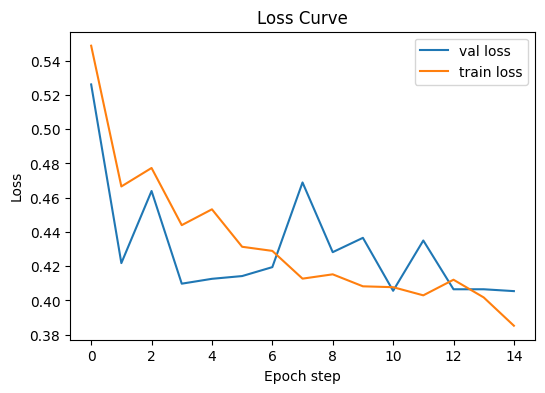


TEST RESULTS
eval_loss: 0.4294
eval_accuracy: 0.7998
eval_precision: 0.7819
eval_recall: 0.8314
eval_f1: 0.8059
eval_runtime: 27.5005
eval_samples_per_second: 909.0750
eval_steps_per_second: 28.4360
epoch: 15.0000

Trainable parameters: 100674


In [6]:
# Install and load packages
#!pip install transformers datasets evaluate scikit-learn matplotlib -q
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
)
import evaluate

#1. DATA
from datasets import load_dataset
imdb = load_dataset("imdb")
train_sample = imdb["train"].shuffle(seed=42).select(range(5000))
train_valid = train_sample.train_test_split(test_size=0.2, seed=42)
train_data = train_valid["train"]
val_data = train_valid["test"]
test_data = imdb["test"]

# subsample: using the same training, validation and test data as problem 1
train_dataset = train_data   # 4000 samples
val_dataset   = val_data     # 1000 samples
test_dataset  = test_data    # full 25k

#2. TOKENIZER
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
MAX_LEN = 128

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

for ds in [train_dataset, val_dataset, test_dataset]:
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Helper functions
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
        }

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


#3. MODEL: Adapter‑based PEFT
class BottleneckAdapter(nn.Module):
    def __init__(self, hidden_dim=768, bottleneck_dim=64):
        super().__init__()
        self.down = nn.Linear(hidden_dim, bottleneck_dim)
        self.up   = nn.Linear(bottleneck_dim, hidden_dim)
        self.act  = nn.ReLU()

        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)
        nn.init.xavier_uniform_(self.down.weight)
        nn.init.zeros_(self.down.bias)

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))

class AdapterModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("distilbert-base-uncased")

        for p in self.encoder.parameters():
            p.requires_grad = False

        self.adapter = BottleneckAdapter()
        self.classifier = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        x = self.adapter(cls)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits}

#4. TRAINER
class AdapterTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels", None)
        outputs = model(**inputs, labels=labels)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

# MODEL SETUP
model_peft = AdapterModel()

BATCH_SIZE = 32
EPOCHS = 15

training_args = TrainingArguments(
    output_dir="./adapter_fast",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=1e-3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    max_grad_norm=1.0,
    logging_steps=100,
    report_to="none",
    fp16=True,
)

trainer_peft = AdapterTrainer(
    model=model_peft,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer_peft.train()

#5. LOSS PLOT
def plot_losses(log_history):
    train_losses, eval_losses = [], []

    for x in log_history:
        if "loss" in x:
            train_losses.append(x["loss"])
        if "eval_loss" in x:
            eval_losses.append(x["eval_loss"])

    plt.figure(figsize=(6,4))
    plt.plot(eval_losses, label="val loss")
    plt.plot(train_losses[:len(eval_losses)], label="train loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch step")
    plt.ylabel("Loss")
    plt.show()

plot_losses(trainer_peft.state.log_history)

#6. TEST EVALUATION
results_peft = trainer_peft.evaluate(test_dataset)

print("\nTEST RESULTS")
for k, v in results_peft.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

trainable_params = sum(p.numel() for p in model_peft.parameters() if p.requires_grad)
print("\nTrainable parameters:", trainable_params)

In [7]:
#================================================
# COMPARE THREE MODELS

comparison = pd.DataFrame([
    {
        "Model": "Full Fine-Tuning",
        "Trainable Params": f"{count_trainable_params(model):,}",
        "Accuracy":  f"{results.get('eval_accuracy', float('nan')):.4f}",
        "Precision": f"{results.get('eval_precision', float('nan')):.4f}",
        "Recall":    f"{results.get('eval_recall', float('nan')):.4f}",
        "F1-score":  f"{results.get('eval_f1', float('nan')):.4f}",
    },
    {
        "Model": "LoRA ",
        "Trainable Params": f"{count_trainable_params(model_lora):,}",
        "Accuracy":  f"{results_lora.get('eval_accuracy', float('nan')):.4f}",
        "Precision": f"{results_lora.get('eval_precision', float('nan')):.4f}",
        "Recall":    f"{results_lora.get('eval_recall', float('nan')):.4f}",
        "F1-score":  f"{results_lora.get('eval_f1', float('nan')):.4f}",
    },
    {
        "Model": "LoRA (Adapter-based PEFT) - Test",
        "Trainable Params": f"{sum(p.numel() for p in model_peft.parameters() if p.requires_grad):,}",
        "Accuracy":  f"{results_peft.get('eval_accuracy', float('nan')):.4f}",
        "Precision": f"{results_peft.get('eval_precision', float('nan')):.4f}",
        "Recall":    f"{results_peft.get('eval_recall', float('nan')):.4f}",
        "F1-score":  f"{results_peft.get('eval_f1', float('nan')):.4f}",
    },
])

comparison.set_index("Model", inplace=True)

print("\n=== IMDB Model Comparison ===")
print(comparison.to_string())


=== IMDB Model Comparison ===
                                 Trainable Params Accuracy Precision  Recall F1-score
Model                                                                                
Full Fine-Tuning                       66,955,010   0.8489    0.8330  0.8728   0.8524
LoRA                                      739,586   0.8006    0.8047  0.7938   0.7992
LoRA (Adapter-based PEFT) - Test          100,674   0.7998    0.7819  0.8314   0.8059


## Adapter model design
The model uses a frozen DistilBERT encoder with a bottleneck adapter of the form

  $$h' = h + W_{up} \sigma(W_{down} h),$$

where the hidden size is $d = 768$, bottleneck dimension $r = 64$, and $\sigma = \text{ReLU}$. The adapter is applied to the CLS embedding, followed by a linear classifier producing two logits. The adapter is initialized with $W_{up} = 0$ (and zero biases) and $W_{down}$ using Xavier uniform initialization, resulting in a near-identity mapping ($h' \approx h$) at initialization, which stabilizes training and preserves pretrained representations. Training uses a learning rate of $1\mathrm{e}{-3}$, batch size 32, 10 epochs, maximum sequence length 128, weight decay 0.01, gradient clipping 1.0, and fp16 for GPU. The total number of trainable parameters is 100,674 (adapter + classifier).



## Discussion

- **Performance comparison**: The adapter model (79.98% accuracy, F1=0.8059) performs comparably to LoRA (80.06%, F1=0.7992) and approaches full fine‑tuning (84.89%, F1=0.8524). Notably, the adapter achieves recall (83.14%) higher than LoRA (79.38%), though its precision is slightly lower (78.19% vs. 80.47%). Overall, all three methods yield reasonably comparable results, with full fine‑tuning remaining the best model.

- **Parameter efficiency**: The adapter model is the most parameter‑efficient, using only **100,674 trainable parameters**—about 7.3× fewer than LoRA (739,586) and 665× fewer than full fine‑tuning (66.96M). It achieves competitive performance with a fraction of the parameters, making it the clear winner for efficiency.

- **Preference for many sentiment tasks**: For multiple sentiment tasks sharing the same DistilBERT backbone, I would prefer **adapters**. Adapters are modular—each task has a small, isolated set of parameters—allowing easy task switching without interference. LoRA modifies the same weight matrices across tasks, requiring careful merging or multiple copies. Adapters scale more efficiently and cleanly when managing many tasks.